# 0. 환경설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 1. 개요 — 05번 이후 파생 질문과 변수 진단

05_04XJoin.ipynb에서는 04번 8장의 6개 질문(Q1~Q6)을 courses·studentRegistration·studentVle·assessments 조인으로 검증했다. 05번 각 질문의 `설명` 구간에는 결론을 내리는 대신 후속 질문으로 남겨둔 지점들이 있었다.

1. **Q2(취소-제출 간격) × Q6(미제출 평가)**: 학생이 "평가를 처음 놓친 시점"이 실제 "등록취소일"보다 앞서는가? 05번 Q6 설명에서 지적한 인과 방향(놓친 평가가 이탈의 원인인지 결과인지) 문제를 시계열 순서로 확인한다.
2. **Q3(VLE 조인) 세분화**: 05번은 총 클릭 수·활동 일수만 집계했다. vle.csv의 `activity_type`(자료 유형)까지 조인하면 이탈 그룹이 구체적으로 어떤 유형의 활동에서 더 크게 빠지는지 볼 수 있다.
3. **Q3의 시계열 후속**: 학기 전반부 대비 후반부 클릭 수 변화(감소 추세)를 보면 이탈의 조기 경보 신호로 쓸 수 있는지 확인할 수 있다.
4. **Q5(is_banked) 재해석**: is_banked는 정의상 재수강(`num_of_prev_attempts>0`)과 강하게 얽혀 있다. 재수강 여부·is_banked·이탈률을 함께 봐야 05번에서 "부분적 설명"으로 남긴 결론을 더 명확히 할 수 있다.

이번 06번에서는 위 4가지를 Q7~Q10으로 이어서 검증한다. 모델링용 통합 테이블(전체 CSV를 하나로 합치는 "통합 작업")은 아직 만들지 않고, 질문별로 필요한 CSV만 그때그때 조인하는 05번까지의 방식을 유지한다.

추가로 지금까지 살펴본 변수들을 모아 두 가지 진단을 수행한다.

- **범주형 변수 간 독립성**: gender·region·highest_education·imd_band·age_band·disability·code_module·code_presentation 8개 변수가 서로 얼마나 겹치는 정보를 담고 있는지 카이제곱검정과 Cramér's V로 확인한다. 이후 모델링에서 여러 인구통계 변수를 동시에 넣을 때 중복 신호가 있는지 미리 점검하는 목적이다.
- **수치형 파생변수 간 다중공선성**: 지금까지 파생시킨 참여도 지표(총 클릭 수, 활동 일수, 제출 건수, 평균 점수, 미제출 weight 등)를 한 테이블에 모아 상관행렬과 VIF(분산팽창지수)를 계산한다. 이 지표들은 개념적으로 "얼마나 활발히 참여했는가"라는 하나의 축을 여러 각도에서 재는 것이라 서로 강하게 겹칠 가능성이 높다.

# 2. 데이터 로드 및 조인 준비

In [ ]:
info = pd.read_csv('../../CSV_files/studentInfo.csv')
info['label_churn'] = (info['final_result'] == 'Withdrawn').astype(int)

sa = pd.read_csv('../../CSV_files/studentAssessment.csv')
asm = pd.read_csv('../../CSV_files/assessments.csv')
courses = pd.read_csv('../../CSV_files/courses.csv')
reg = pd.read_csv('../../CSV_files/studentRegistration.csv')
vle_meta = pd.read_csv('../../CSV_files/vle.csv')
vle = pd.read_csv('../../CSV_files/studentVle.csv')

# 05번과 동일한 기준 조인 테이블
df = sa.merge(asm, on='id_assessment', how='left')
df = df.merge(info[['code_module', 'code_presentation', 'id_student', 'final_result', 'label_churn']],
              on=['code_module', 'code_presentation', 'id_student'], how='left')
df['delay'] = df['date_submitted'] - df['date']

# 학생-과목 단위 roster (studentInfo 전체 기준)
roster = info[['code_module', 'code_presentation', 'id_student', 'label_churn', 'final_result']].drop_duplicates()

# 학생별 마지막 제출일 (05번 Q2)
last_sub = df.groupby(['code_module', 'code_presentation', 'id_student'])['date_submitted'].max().reset_index()
last_sub.columns = ['code_module', 'code_presentation', 'id_student', 'last_submit_date']

# 기대 평가 로스터 vs 실제 제출 anti-join → 미제출(결석) 식별 (05번 Q6)
expected = roster[['code_module', 'code_presentation', 'id_student']].merge(
    asm[['id_assessment', 'code_module', 'code_presentation', 'assessment_type', 'date', 'weight']],
    on=['code_module', 'code_presentation'], how='left')
submitted_pairs = df[['code_module', 'code_presentation', 'id_student', 'id_assessment']].drop_duplicates()
submitted_pairs['submitted'] = True
merged = expected.merge(submitted_pairs, on=['code_module', 'code_presentation', 'id_student', 'id_assessment'], how='left')
merged['submitted'] = merged['submitted'].notna()
missing = merged[~merged['submitted']]
miss_noexam = missing[missing['assessment_type'] != 'Exam']  # Exam은 구조적으로 놓칠 수밖에 없어 제외 (04·05와 동일 기준)

print(f'info: {len(info):,}건 / vle: {len(vle):,}행 / vle_meta(activity 정의): {len(vle_meta):,}건')
print(f'df(제출 기록): {len(df):,}건 / roster(학생-과목): {len(roster):,}건 / 미제출(Exam제외): {len(miss_noexam):,}건')

info: 32,593건 / vle: 10,655,280행 / vle_meta(activity 정의): 6,364건
df(제출 기록): 173,912건 / roster(학생-과목): 32,593건 / 미제출(Exam제외): 117,945건


## Q7. 미제출 평가 시점과 실제 이탈(등록취소)일의 순서 — 인과 방향 재확인

#### 배경

05번 Q6은 "미제출 평가의 weight"가 완주-이탈 간 격차가 크다는 것을 확인했지만, 이 지표가 이탈의 **원인**인지 이탈 과정의 **결과**(제출을 멈추면서 자연히 이후 평가도 놓치게 됨)인지는 구분하지 못했다. 05번 Q2에서 만든 `date_unregistration`(공식 등록취소일)을 이용해, 학생이 평가를 처음 놓친 시점과 공식적으로 이탈한 시점의 순서를 직접 비교한다.

In [ ]:
# 근거 : (1차 시도) 첫 미제출일 vs 등록취소일 — 단순 비교
first_missed = miss_noexam.groupby(['code_module', 'code_presentation', 'id_student'])['date'].min().reset_index()
first_missed.columns = ['code_module', 'code_presentation', 'id_student', 'first_missed_date']

wd = roster[roster['final_result'] == 'Withdrawn'].merge(reg, on=['code_module', 'code_presentation', 'id_student'], how='left')
wd = wd.merge(last_sub, on=['code_module', 'code_presentation', 'id_student'], how='left')
wd = wd.merge(first_missed, on=['code_module', 'code_presentation', 'id_student'], how='left')

both = wd.dropna(subset=['date_unregistration', 'first_missed_date']).copy()
both['gap_unreg_missed'] = both['date_unregistration'] - both['first_missed_date']

print('Withdrawn 전체:', len(wd))
print('취소일·첫 미제출일 둘 다 있는 경우:', len(both))
print(both['gap_unreg_missed'].describe().round(2))
print('첫 미제출이 취소일보다 먼저(gap>0):', round((both['gap_unreg_missed'] > 0).mean(), 4))
print('첫 미제출이 취소일보다 나중(gap<0):', round((both['gap_unreg_missed'] < 0).mean(), 4))

Withdrawn 전체: 10156
취소일·첫 미제출일 둘 다 있는 경우: 9975
count    9975.00
mean       -4.61
std        58.64
min      -389.00
25%       -31.00
50%        -8.00
75%        14.00
max       313.00
Name: gap_unreg_missed, dtype: float64
첫 미제출이 취소일보다 먼저(gap>0): 0.365
첫 미제출이 취소일보다 나중(gap<0): 0.6161


In [ ]:
# 근거 : (2차 시도) 등록취소 이전에 마감이었던(재적 중 실제로 놓칠 수 있었던) 평가만으로 재계산
# → 평가 마감일은 학생의 이탈 여부와 무관하게 학기 캘린더상 고정되어 있으므로,
#    취소 이후에 마감된 평가까지 '미제출'로 잡으면 첫 미제출 시점이 인위적으로 뒤로 밀린다.
wd_unreg = roster[roster['final_result'] == 'Withdrawn'].merge(
    reg[['code_module', 'code_presentation', 'id_student', 'date_unregistration']],
    on=['code_module', 'code_presentation', 'id_student'], how='left')
miss_with_unreg = miss_noexam.merge(wd_unreg, on=['code_module', 'code_presentation', 'id_student'], how='inner')
miss_with_unreg = miss_with_unreg.dropna(subset=['date_unregistration'])
before = miss_with_unreg[miss_with_unreg['date'] <= miss_with_unreg['date_unregistration']]

print(f'전체 미제출(Exam 제외): {len(miss_noexam):,}건 / 그중 취소 이전 마감(재적 중 실제로 놓친) 건: {len(before):,}건')

first_missed_valid = before.groupby(['code_module', 'code_presentation', 'id_student'])['date'].min().reset_index()
first_missed_valid.columns = ['code_module', 'code_presentation', 'id_student', 'first_missed_valid_date']

wd2 = wd.merge(first_missed_valid, on=['code_module', 'code_presentation', 'id_student'], how='left')
both3 = wd2.dropna(subset=['date_unregistration', 'first_missed_valid_date']).copy()
both3['gap_valid'] = both3['date_unregistration'] - both3['first_missed_valid_date']

print(f'재적 중 실제로 평가를 놓친 Withdrawn: {len(both3):,}명 / 전체 Withdrawn {len(wd2):,}명 ({len(both3)/len(wd2):.1%})')
print(both3['gap_valid'].describe().round(2))

전체 미제출(Exam 제외): 117,945건 / 그중 취소 이전 마감(재적 중 실제로 놓친) 건: 7,770건
재적 중 실제로 평가를 놓친 Withdrawn: 3,829명 / 전체 Withdrawn 10,156명 (37.7%)
count    3829.00
mean       46.79
std        48.39
min         0.00
25%         8.00
50%        30.00
75%        70.00
max       313.00
Name: gap_valid, dtype: float64


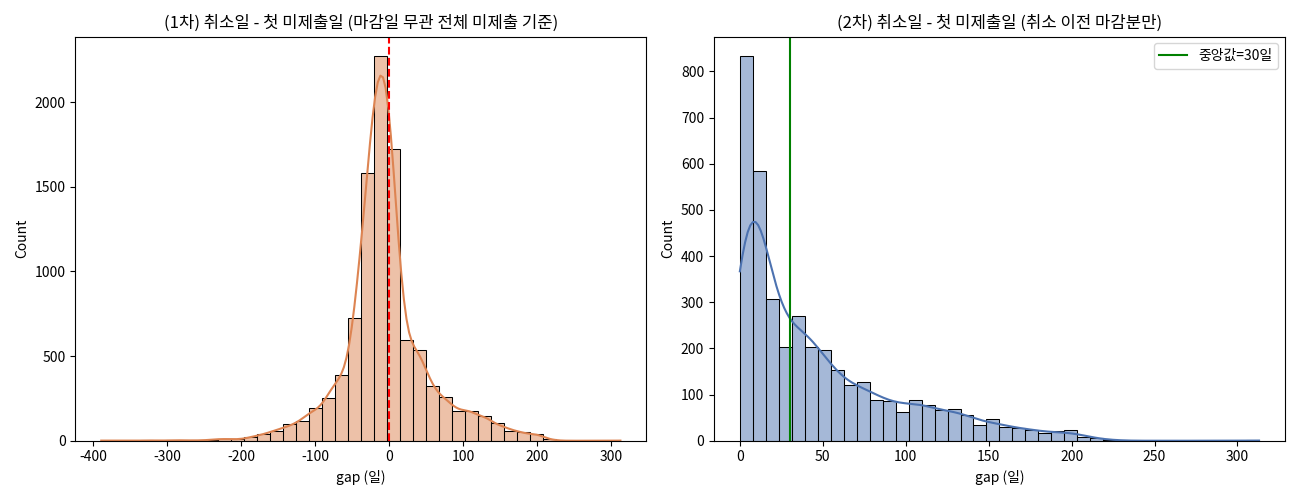

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(both['gap_unreg_missed'], bins=40, kde=True, color='#DD8452', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('(1차) 취소일 - 첫 미제출일 (마감일 무관 전체 미제출 기준)')
axes[0].set_xlabel('gap (일)')

sns.histplot(both3['gap_valid'], bins=40, kde=True, color='#4C72B0', ax=axes[1])
axes[1].axvline(both3['gap_valid'].median(), color='green', linestyle='-',
                 label=f"중앙값={both3['gap_valid'].median():.0f}일")
axes[1].set_title('(2차) 취소일 - 첫 미제출일 (취소 이전 마감분만)')
axes[1].set_xlabel('gap (일)')
axes[1].legend()

plt.tight_layout()
plt.show()

#### 설명

1차 시도(마감일과 무관하게 모든 미제출을 포함)에서는 첫 미제출일이 취소일보다 **나중**인 경우가 61.6%로 더 많았다(gap 중앙값 -8일). 이는 인과관계가 뒤집힌 것이 아니라, 평가 마감일이 학생의 이탈 여부와 무관하게 학기 캘린더상 고정되어 있어서 발생하는 착시다 — 학생이 일찍 이탈하면 그 이후 마감인 평가들이 전부 '미제출'로 잡히기 때문에 '첫 미제출일'이 실제 이탈 시점보다 한참 뒤로 계산된다.

이 착시를 걷어내기 위해 **등록취소 이전에 마감이었던 평가**(재적 중에 실제로 놓칠 수 있었던 평가)만으로 다시 계산하면, Withdrawn 10,156명 중 3,829명(37.7%)만 재적 기간 중 실제로 평가를 놓친 이력이 있다. 이 3,829명만 보면 첫 미제출 시점부터 공식 취소까지 평균 46.8일(중앙값 30일)이 걸린다 — 즉 이 하위 집단에서는 "평가를 놓친 시점"이 "공식 이탈 시점"보다 약 한 달 앞서는 선행 신호로 쓸 수 있다.

다만 나머지 62.3%(6,327명)의 Withdrawn 학생은 재적 중 놓친 TMA/CMA 자체가 없다 — 애초에 제출 이력이 거의 없이(05번 Q1의 '제출 이력 없는 고위험군') 조기 이탈했거나, 평가 마감일이 오기 전에 이미 등록을 취소한 경우다. 따라서 "놓친 평가"는 **재적 중 마감을 맞이한 학생 한정으로만** 이탈의 선행 신호이며, 전체 이탈 그룹에 일반화하기는 어렵다.

## Q8. VLE 활동 유형(activity_type)별 참여 차이 — 어떤 콘텐츠에서 더 크게 이탈하는가

#### 배경

05번 Q3은 studentVle.csv를 총 클릭 수·활동 일수로만 집계해 "이탈 그룹의 온라인 활동이 전반적으로 줄어든다"는 것만 확인했다. vle.csv에는 각 자료(`id_site`)가 어떤 유형(`activity_type`: 강의자료, 퀴즈, 게시판 등)인지 정의되어 있다. 이를 조인하면 이탈 그룹이 구체적으로 어떤 유형의 콘텐츠에서 더 크게 발을 빼는지 볼 수 있다.

In [ ]:
# 근거 : studentVle + vle(activity_type) 조인, label_churn 부착
vle_full = vle.merge(vle_meta[['id_site', 'code_module', 'code_presentation', 'activity_type']],
                      on=['id_site', 'code_module', 'code_presentation'], how='left')
vle_full = vle_full.merge(roster[['code_module', 'code_presentation', 'id_student', 'label_churn']],
                           on=['code_module', 'code_presentation', 'id_student'], how='left')
print('activity_type 결측:', vle_full['activity_type'].isna().sum(), '/', len(vle_full))

# 근거 : label_churn별 전체 클릭 중 activity_type 비중
type_share = vle_full.groupby(['label_churn', 'activity_type'])['sum_click'].sum().reset_index()
type_share['share'] = type_share['sum_click'] / type_share.groupby('label_churn')['sum_click'].transform('sum')
pivot = type_share.pivot(index='activity_type', columns='label_churn', values='share').fillna(0)
pivot.columns = ['완주_비중', '이탈_비중']
pivot['비중차이(이탈-완주)'] = (pivot['이탈_비중'] - pivot['완주_비중']).round(4)
pivot = pivot.round(4).sort_values('비중차이(이탈-완주)')
print(pivot)

activity_type 결측: 0 / 10655280
                 완주_비중   이탈_비중  비중차이(이탈-완주)
activity_type                              
oucontent       0.2866  0.2412      -0.0454
quiz            0.1782  0.1539      -0.0244
ouwiki          0.0231  0.0167      -0.0064
dataplus        0.0013  0.0001      -0.0012
questionnaire   0.0017  0.0010      -0.0007
glossary        0.0022  0.0020      -0.0003
folder          0.0001  0.0000      -0.0001
dualpane        0.0005  0.0004      -0.0001
repeatactivity  0.0000  0.0000       0.0000
oucollaborate   0.0028  0.0028       0.0000
sharedsubpage   0.0000  0.0000       0.0000
ouelluminate    0.0010  0.0012       0.0002
htmlactivity    0.0002  0.0007       0.0005
externalquiz    0.0016  0.0022       0.0006
page            0.0015  0.0027       0.0012
url             0.0140  0.0175       0.0034
forumng         0.2006  0.2092       0.0086
resource        0.0270  0.0397       0.0127
homepage        0.1735  0.1983       0.0249
subpage         0.0840  0.1105       0.0265


In [ ]:
# 근거 : 학생-과목-activity_type 단위로 "해당 유형을 한 번이라도 이용했는지" 참여율 계산
stu_type = vle_full.groupby(['code_module', 'code_presentation', 'id_student', 'activity_type'])['sum_click'].sum().reset_index()
stu_type_wide = stu_type.pivot_table(index=['code_module', 'code_presentation', 'id_student'],
                                      columns='activity_type', values='sum_click', fill_value=0).reset_index()
stu_type_wide = stu_type_wide.merge(roster[['code_module', 'code_presentation', 'id_student', 'label_churn']],
                                     on=['code_module', 'code_presentation', 'id_student'], how='left')

main_types = ['oucontent', 'quiz', 'forumng', 'homepage', 'subpage', 'resource', 'url', 'ouwiki', 'oucollaborate']
part_rate = pd.DataFrame({
    t: stu_type_wide.groupby('label_churn').apply(lambda g, t=t: (g[t] > 0).mean(), include_groups=False)
    for t in main_types
}).T
part_rate.columns = ['완주_참여율', '이탈_참여율']
part_rate['차이(완주-이탈)'] = (part_rate['완주_참여율'] - part_rate['이탈_참여율']).round(4)
print(part_rate.round(4).sort_values('차이(완주-이탈)', ascending=False))

               완주_참여율  이탈_참여율  차이(완주-이탈)
quiz           0.7361  0.5211     0.2150
forumng        0.9303  0.7649     0.1654
oucollaborate  0.4112  0.2538     0.1574
ouwiki         0.3982  0.2556     0.1426
resource       0.9703  0.8638     0.1064
url            0.8400  0.7492     0.0909
oucontent      0.9427  0.8546     0.0881
subpage        0.9830  0.9103     0.0727
homepage       0.9993  0.9961     0.0032


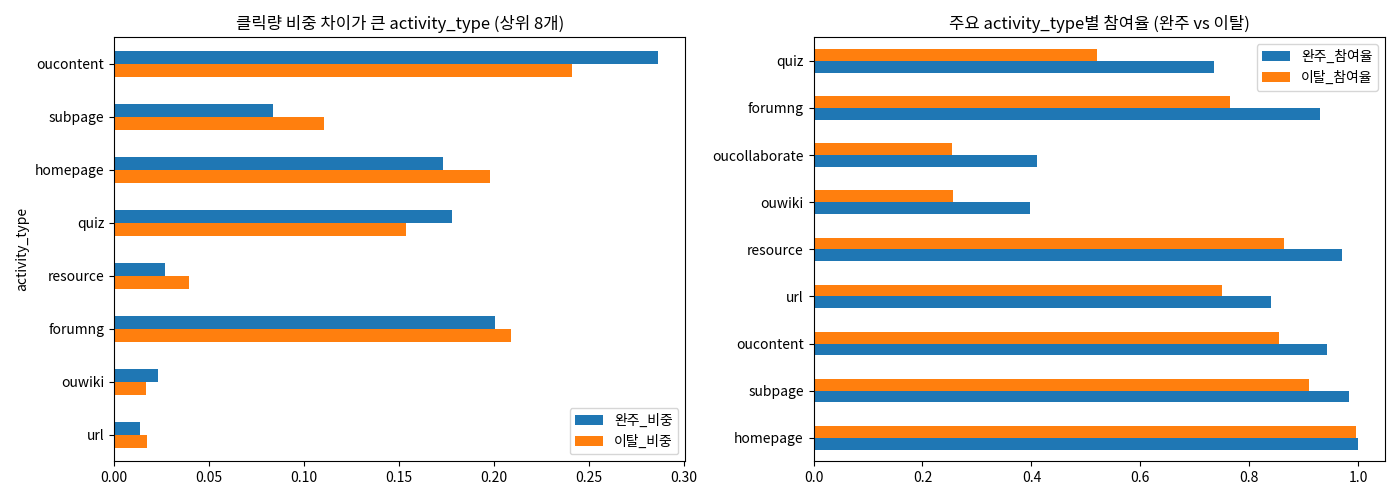

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_share = pivot.reindex(pivot['비중차이(이탈-완주)'].abs().sort_values(ascending=False).index).head(8)
top_share[['완주_비중', '이탈_비중']].plot(kind='barh', ax=axes[0])
axes[0].set_title('클릭량 비중 차이가 큰 activity_type (상위 8개)')
axes[0].invert_yaxis()

part_rate.sort_values('차이(완주-이탈)', ascending=True)[['완주_참여율', '이탈_참여율']].plot(kind='barh', ax=axes[1])
axes[1].set_title('주요 activity_type별 참여율 (완주 vs 이탈)')

plt.tight_layout()
plt.show()

#### 설명

클릭량 비중으로 보면 `oucontent`(강의자료 열람)의 비중 차이가 가장 크다(완주 28.7% → 이탈 24.1%, -4.5%p). `quiz`도 완주 17.8% → 이탈 15.4%(-2.4%p)로 뒤를 잇는다. 반대로 `forumng`(게시판)·`homepage`·`subpage`는 이탈 그룹에서 오히려 비중이 소폭 높아지는데, 이는 실제 참여가 늘어서라기보다 절대 클릭 수 자체가 급감한 상태에서 상대 비중만 재계산된 결과로 해석해야 한다(Q3에서 확인했듯 이탈 그룹의 총 클릭 수 자체가 완주 그룹의 약 1/5 수준).

더 뚜렷한 신호는 "해당 유형을 한 번이라도 이용했는가"라는 참여율이다. `quiz`(자가진단 퀴즈) 참여율이 완주 73.6% → 이탈 52.1%로 21.5%p 차이 나 가장 크게 벌어진다. `oucontent` 참여율도 94.3% → 85.5%(8.8%p)로 여전히 차이가 있지만, 애초에 두 그룹 다 참여율 자체가 높아(90% 이상) 변별력은 quiz보다 작다. 즉 콘텐츠를 '열람'하는 수동적 활동보다, 퀴즈처럼 결과가 즉시 확인되는 '능동적' 활동에서 이탈 그룹의 이탈이 먼저, 더 크게 나타난다고 볼 수 있다.

## Q9. 학기 전반부 대비 후반부 클릭 수 변화 — 조기 경보 신호로 쓸 수 있는가

#### 배경

Q3(05번)·Q8에서 이탈 그룹의 VLE 활동이 전반적으로 적다는 것은 확인했지만, 이는 '누적 총량' 비교일 뿐 학기 중 활동이 언제 줄어드는지는 보여주지 않는다. `courses.csv`의 `module_presentation_length`를 기준으로 학기를 전/후반으로 나눠, 각 학생의 클릭 수가 후반부에 얼마나 줄어드는지(감소율)를 계산한다. 전반부에 활동이 없으면애초에 '감소'를 논할 수 없으므로, 전반부 클릭이 1건이라도 있는 학생만 대상으로 한다.

In [ ]:
# 근거 : 학기 절반 시점을 기준으로 전/후반 클릭 수 집계
vle2 = vle.merge(courses, on=['code_module', 'code_presentation'], how='left')
vle2['half'] = np.where(vle2['date'] < vle2['module_presentation_length'] / 2, 'first', 'second')

half_click = vle2.groupby(['code_module', 'code_presentation', 'id_student', 'half'])['sum_click'].sum().reset_index()
half_wide = half_click.pivot_table(index=['code_module', 'code_presentation', 'id_student'],
                                    columns='half', values='sum_click', fill_value=0).reset_index()
for c in ['first', 'second']:
    if c not in half_wide.columns:
        half_wide[c] = 0
half_wide = half_wide.merge(roster[['code_module', 'code_presentation', 'id_student', 'label_churn']],
                             on=['code_module', 'code_presentation', 'id_student'], how='left')

has_first = half_wide[half_wide['first'] > 0].copy()
has_first['ratio'] = has_first['second'] / has_first['first']  # 1보다 작으면 후반부 감소

print('전반부 VLE 활동이 있었던 학생-과목:', len(has_first))
print()
print('label_churn별 후반부/전반부 클릭 비율(ratio) 통계:')
print(has_first.groupby('label_churn')['ratio'].agg(['mean', 'median', 'count']).round(3))
print()
print('label_churn별 후반부 클릭이 0으로 완전히 끊긴 비율:')
print(has_first.groupby('label_churn').apply(lambda g: (g['second'] == 0).mean(), include_groups=False).round(4))
print()
print('label_churn별 전/후반 클릭 절대량 평균:')
print(has_first.groupby('label_churn')[['first', 'second']].mean().round(1))

전반부 VLE 활동이 있었던 학생-과목: 29204

label_churn별 후반부/전반부 클릭 비율(ratio) 통계:
              mean  median  count
label_churn                      
0            0.935   0.608  22042
1            0.060   0.000   7162

label_churn별 후반부 클릭이 0으로 완전히 끊긴 비율:
label_churn
0    0.1337
1    0.7954
dtype: float64

label_churn별 전/후반 클릭 절대량 평균:
             first  second
label_churn               
0            969.1   683.0
1            413.2    32.0


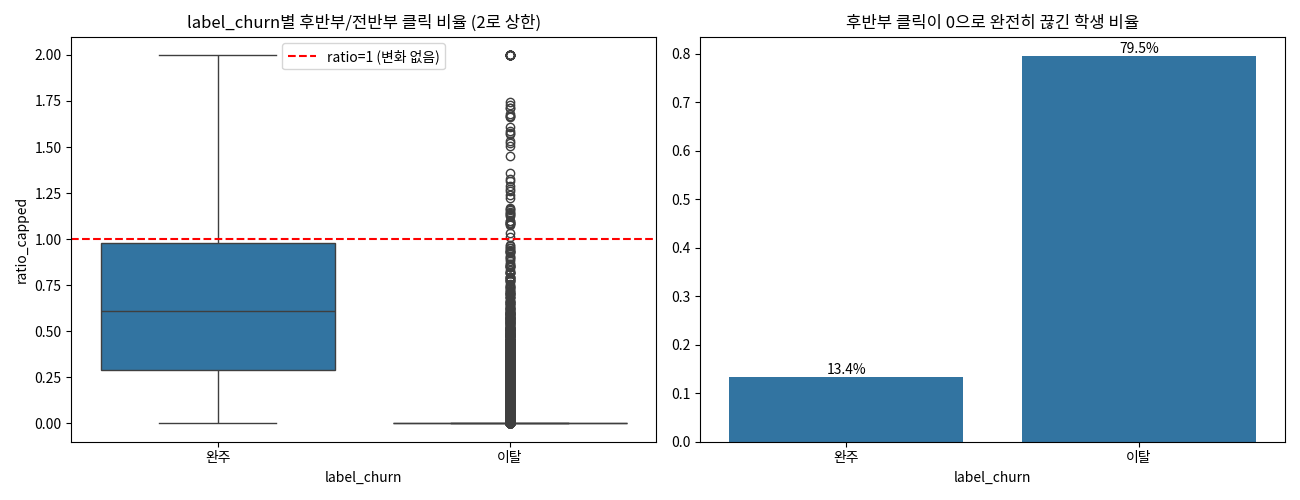

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ratio_capped = has_first.copy()
ratio_capped['ratio_capped'] = ratio_capped['ratio'].clip(upper=2)
sns.boxplot(data=ratio_capped, x='label_churn', y='ratio_capped', ax=axes[0])
axes[0].axhline(1, color='red', linestyle='--', label='ratio=1 (변화 없음)')
axes[0].set_title('label_churn별 후반부/전반부 클릭 비율 (2로 상한)')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['완주', '이탈']); axes[0].legend()

stop_rate = has_first.groupby('label_churn').apply(lambda g: (g['second'] == 0).mean(), include_groups=False)
sns.barplot(x=stop_rate.index.astype(str), y=stop_rate.values, ax=axes[1])
axes[1].set_title('후반부 클릭이 0으로 완전히 끊긴 학생 비율')
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['완주', '이탈'])
for i, v in enumerate(stop_rate.values):
    axes[1].text(i, v, f'{v:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### 설명

전반부에 VLE 활동이 있었던 29,204개 학생-과목 조합 중, 완주 그룹은 후반부/전반부 클릭 비율의 중앙값이 0.608로 활동이 어느 정도 유지되는 반면(평균도 0.935로 1에 가까움), 이탈 그룹은 중앙값이 **0**이다 — 즉 이탈 그룹의 절반 이상은 후반부에 클릭이 아예 없다. 실제로 후반부 클릭이 완전히 0인 비율은 완주 13.4% vs 이탈 79.5%로 6배 가까이 차이 난다. 절대량으로도 완주 그룹은 전반부 969회 → 후반부 683회(30% 감소)로 완만하게 줄어드는 반면, 이탈 그룹은 413회 → 32회(92% 감소)로 사실상 활동이 끊긴다.

이 지표는 05번 Q3의 '누적 클릭 수'보다 훨씬 뚜렷한 이탈 신호다. 다만 이 지표를 실시간 조기경보로 쓰려면 '학기 절반 시점'이 지나야 계산할 수 있다는 한계가 있어, 실제 운영에서는 전/후반이 아니라 더 짧은 구간(예: 2~4주 단위 이동평균)으로 세분화해 조기 탐지 시점을 앞당기는 후속 작업이 필요하다.

## Q10. is_banked × 재수강(num_of_prev_attempts) — 05번 Q5 결론 재해석

#### 배경

05번 Q5는 `date_registration`과 비교해 is_banked=1 학생 중 일부(6.02%)가 개강 이후 늦게 등록했다는 것을 확인했지만, "나머지는 다른 요인(예: 과목 재수강 패턴)을 봐야 한다"고 남겨뒀다. is_banked는 정의상 이전 시도의 점수를 이월받는 것이므로 재수강(`num_of_prev_attempts > 0`)과 구조적으로 얽혀 있다. 재수강 여부·is_banked·이탈률을 함께 봐서 05번 Q5의 나머지 설명을 채운다.

In [ ]:
# 근거 : 학생-과목 단위 is_banked 여부(둘 이상 평가 중 하나라도 banked면 1)와 재수강 여부 결합
stu_banked = df.groupby(['code_module', 'code_presentation', 'id_student'])['is_banked'].max().reset_index()
stu = info.merge(stu_banked, on=['code_module', 'code_presentation', 'id_student'], how='left')
stu['is_banked'] = stu['is_banked'].fillna(0)
stu['is_repeat'] = (stu['num_of_prev_attempts'] > 0).astype(int)

print('재수강 여부별 is_banked=1 비율:')
print(stu.groupby('is_repeat')['is_banked'].mean().round(4))
print()
print('재수강 여부별 이탈률:')
print(stu.groupby('is_repeat')['label_churn'].mean().round(4))
print()
print('재수강×is_banked 교차 이탈률:')
print(stu.groupby(['is_repeat', 'is_banked'])['label_churn'].agg(['mean', 'count']).round(4))
print()
print('num_of_prev_attempts별 이탈률:')
print(stu.groupby('num_of_prev_attempts')['label_churn'].agg(['mean', 'count']).round(4))

ct = pd.crosstab(stu['is_repeat'], stu['is_banked'])
chi2, p, dof, exp = chi2_contingency(ct)
print()
print(f'is_repeat × is_banked 카이제곱: {chi2:.2f}, p-value: {p:.2e}')

재수강 여부별 is_banked=1 비율:
is_repeat
0    0.0000
1    0.1261
Name: is_banked, dtype: float64

재수강 여부별 이탈률:
is_repeat
0    0.3056
1    0.3526
Name: label_churn, dtype: float64

재수강×is_banked 교차 이탈률:
                       mean  count
is_repeat is_banked               
0         0.0        0.3056  28421
1         0.0        0.3640   3646
          1.0        0.2738    526

num_of_prev_attempts별 이탈률:
                        mean  count
num_of_prev_attempts               
0                     0.3056  28421
1                     0.3486   3299
2                     0.3659    675
3                     0.3732    142
4                     0.3590     39
5                     0.3846     13
6                     0.5000      4

is_repeat × is_banked 카이제곱: 3634.12, p-value: 0.00e+00


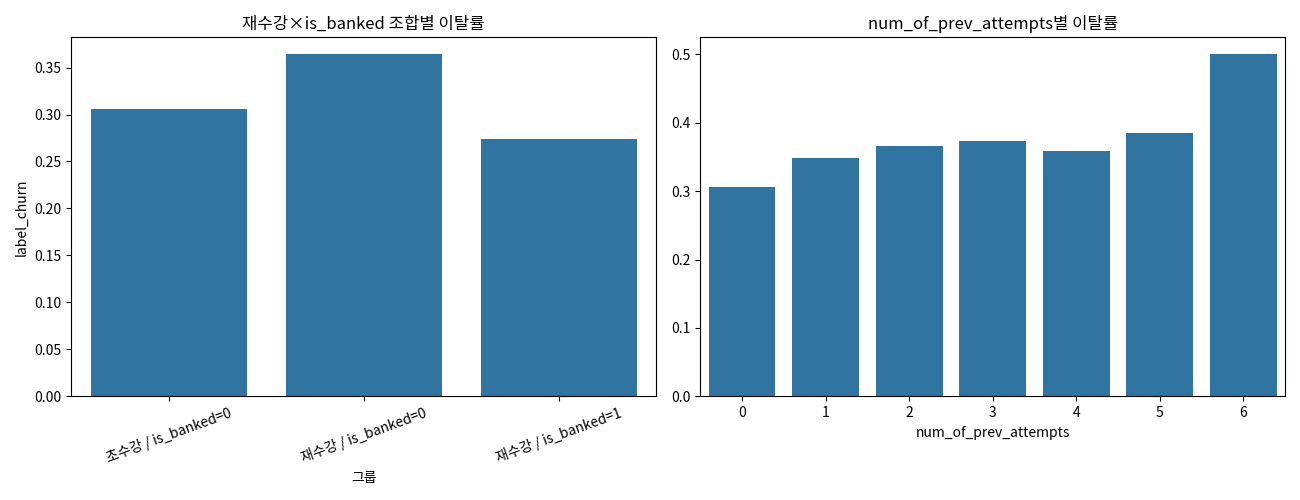

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

grp = stu.groupby(['is_repeat', 'is_banked'])['label_churn'].mean().reset_index()
grp['그룹'] = grp['is_repeat'].map({0: '초수강', 1: '재수강'}) + ' / is_banked=' + grp['is_banked'].astype(int).astype(str)
sns.barplot(data=grp, x='그룹', y='label_churn', ax=axes[0])
axes[0].set_title('재수강×is_banked 조합별 이탈률')
axes[0].tick_params(axis='x', rotation=20)

attempt_churn = stu.groupby('num_of_prev_attempts')['label_churn'].mean()
sns.barplot(x=attempt_churn.index.astype(str), y=attempt_churn.values, ax=axes[1])
axes[1].set_title('num_of_prev_attempts별 이탈률')
axes[1].set_xlabel('num_of_prev_attempts')

plt.tight_layout()
plt.show()

#### 설명

초수강생(`num_of_prev_attempts=0`, 28,421명)은 is_banked=1 비율이 **0%**다 — is_banked는 이전 시도가 있어야만 발생하는, 재수강과 정의상 완전히 종속된 변수임이 재확인된다. is_repeat × is_banked 카이제곱 검정도 χ²=3634.12(p<0.001)로 강한 연관을 보이는데, 이는 통계적 발견이라기보다 정의상 당연한 결과에 가깝다.

흥미로운 지점은 재수강생 내부에서 갈린다. 재수강생 전체 이탈률은 35.3%로 초수강생(30.6%)보다 높지만, 그중 is_banked=1(526명)만 보면 이탈률이 27.4%로 오히려 초수강생보다도 낮고, is_banked=0인 재수강생(3,646명)은 36.4%로 가장 높다. 즉 "재수강 자체"는 이탈 위험을 높이지만, 재수강생 중에서도 **이전 점수를 이월받을 만큼 이전 시도에서 이미 해당 평가를 통과한 학생**(is_banked=1)은 오히려 위험이 낮다 — 04·05번에서 다뤘던 "is_banked=이탈 위험 신호"라는 해석은 재수강생 전체를 대상으로 하면 뒤집힌다. num_of_prev_attempts가 늘어날수록 이탈률이 대체로 높아지는 추세(0회 30.6% → 3회 37.3%)는 유지되지만, is_banked 여부로 한 번 더 나누면 방향이 달라지는 하위집단이 존재한다는 점이 이번 조인의 핵심 발견이다.

## Q7~Q10 요약

| 질문 | 핵심 결과 |
|---|---|
| Q7. 미제출 시점 vs 이탈 시점 | 평가 마감일은 이탈 여부와 무관하게 고정되어 있어 단순 비교는 착시(첫 미제출이 취소보다 나중인 경우 61.6%). 취소 이전 마감분만으로 보면 Withdrawn의 37.7%만 재적 중 실제로 평가를 놓쳤고, 이 경우 놓친 시점이 취소보다 평균 46.8일(중앙값 30일) 앞선다 |
| Q8. activity_type별 참여 차이 | 클릭 비중은 oucontent(-4.5%p)가 가장 크게 줄지만, 참여율 격차는 quiz가 가장 크다(완주 73.6% vs 이탈 52.1%, 21.5%p) — 능동적 활동일수록 이탈 그룹에서 더 크게 이탈 |
| Q9. 전/후반 클릭 변화 | 이탈 그룹은 후반부/전반부 클릭 비율 중앙값 0(79.5%가 후반부 완전히 끊김), 완주 그룹은 0.608(13.4%만 끊김) — 누적 총량보다 훨씬 뚜렷한 이탈 신호 |
| Q10. is_banked × 재수강 | is_banked는 재수강과 정의상 종속(초수강생은 100% is_banked=0). 재수강생 내부에서는 is_banked=1(27.4%)이 is_banked=0(36.4%)보다 이탈률이 낮아, "is_banked=위험 신호"라는 기존 해석이 재수강생 하위집단에서는 뒤집힌다 |


Q7·Q9는 05번에서 다루지 못한 **시간 축**(언제 신호가 나타나는가)을 더했고, Q8·Q10은 05번 결론을 더 세분화된 하위집단·변수 단위로 재해석했다. 특히 Q9의 '전/후반 클릭 감소율'은 지금까지 확인한 지표 중 이탈 여부를 가장 선명하게 가르는 신호로 보인다.

# 3. 변수 진단 — 독립성과 다중공선성

지금까지 01~06번에 걸쳐 여러 변수(원본 컬럼 + 파생 변수)를 확인했다. 이후 모델링 단계로 넘어가기 전에, 이 변수들을 그대로 함께 넣었을 때 생길 수 있는 두 가지 문제를 점검한다.

- **독립성**: 범주형 변수끼리 서로 겹치는 정보를 담고 있으면(연관성이 강하면) 모델에 함께 넣었을 때 중복 신호가 되거나 해석이 꼬일 수 있다.
- **다중공선성**: 수치형 변수끼리 상관이 매우 높으면(VIF가 크면) 회귀 계수의 분산이 커져 개별 변수의 영향력을 신뢰하기 어려워진다.

두 진단 모두 "이번에 확정 짓는" 것이 아니라, 이후 통합·모델링 단계에서 어떤 변수를 대표로 남기고 어떤 변수를 빼거나 합칠지 판단하기 위한 사전 점검이다.

## 1. 범주형 변수 간 독립성 — 카이제곱검정 · Cramér's V

#### 배경

studentInfo.csv의 인구통계 변수(gender, region, highest_education, imd_band, age_band, disability)와 구조 변수(code_module, code_presentation) 총 8개를 대상으로, 모든 쌍에 대해 카이제곱검정과 Cramér's V(0~1, 클수록 강한 연관)를 계산한다. label_churn과의 연관성도 함께 확인해 05번까지 다룬 개별 변수 효과와 비교한다.

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return (np.sqrt(phi2corr / denom) if denom > 0 else np.nan), p

cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability',
            'code_module', 'code_presentation']

rows = []
for a, b in combinations(cat_cols, 2):
    v, p = cramers_v(info[a], info[b])
    rows.append((a, b, round(v, 3), p))
cv_df = pd.DataFrame(rows, columns=['var1', 'var2', 'cramers_v', 'p_value']).sort_values('cramers_v', ascending=False)
print(cv_df.to_string(index=False))

             var1              var2  cramers_v       p_value
           gender       code_module      0.599  0.000000e+00
      code_module code_presentation      0.245  0.000000e+00
highest_education          age_band      0.138 8.844299e-266
           region highest_education      0.137  0.000000e+00
           region          imd_band      0.131  0.000000e+00
         age_band       code_module      0.115 1.830256e-178
highest_education       code_module      0.105 9.278576e-292
highest_education        disability      0.099  5.040067e-69
highest_education          imd_band      0.083 2.129548e-165
           region       code_module      0.083 8.193540e-249
           region        disability      0.082  1.675124e-42
           gender          imd_band      0.078  1.308653e-38
           gender highest_education      0.076  1.871611e-40
           gender            region      0.075  4.352419e-35
         imd_band        disability      0.069  1.779418e-29
       disability       

In [ ]:
# 근거 : label_churn과 각 범주형 변수의 연관성
print('=== label_churn 대비 Cramers V ===')
churn_v = []
for c in cat_cols:
    v, p = cramers_v(info[c], info['label_churn'])
    churn_v.append((c, round(v, 3), p))
    print(f'{c:20s} V={v:.3f}  p={p:.2e}')

churn_v_df = pd.DataFrame(churn_v, columns=['variable', 'cramers_v', 'p_value']).set_index('variable')

=== label_churn 대비 Cramers V ===
gender               V=0.012  p=1.66e-02
region               V=0.075  p=4.55e-35
highest_education    V=0.078  p=1.25e-42
imd_band             V=0.078  p=2.99e-38
age_band             V=0.033  p=4.87e-09
disability           V=0.058  p=1.53e-25
code_module          V=0.177  p=4.65e-218
code_presentation    V=0.068  p=6.91e-33


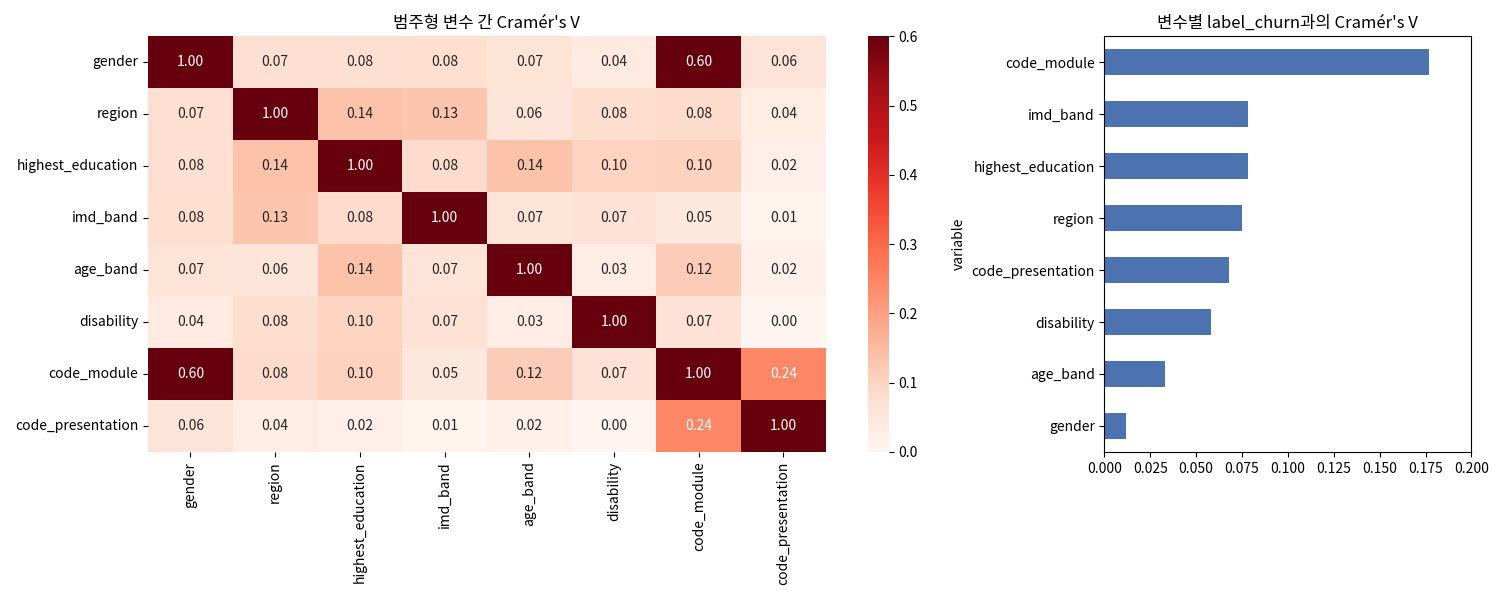

In [ ]:
# 근거 : 변수쌍 Cramer's V 히트맵
mat = pd.DataFrame(1.0, index=cat_cols, columns=cat_cols)
for _, r in cv_df.iterrows():
    mat.loc[r['var1'], r['var2']] = r['cramers_v']
    mat.loc[r['var2'], r['var1']] = r['cramers_v']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1.3]})
sns.heatmap(mat, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=0.6, ax=axes[0])
axes[0].set_title("범주형 변수 간 Cramér's V")

churn_v_df['cramers_v'].sort_values().plot(kind='barh', ax=axes[1], color='#4C72B0')
axes[1].set_title("변수별 label_churn과의 Cramér's V")
axes[1].set_xlim(0, 0.2)

plt.tight_layout()
plt.show()

#### 설명

가장 강한 연관은 `gender`-`code_module`(V=0.599)이다. OULAD 7개 과목 중 CCC·DDD·EEE·FFF·GGG는 이공계열 성격이 강해 남학생 비중이 높고, BBB·AAA 등은 상대적으로 성비가 고르거나 여학생 비중이 높다 — 즉 성별과 수강 과목이 구조적으로 얽혀 있다. `code_module`-`code_presentation`(V=0.245)도 상대적으로 높은데, 이는 04·05번에서 확인했듯 특정 과목이 특정 학기(B/J)에만 개설되는 구조 때문이다(03번 Q2).

나머지 변수쌍은 대부분 V<0.14로 약한 연관에 그친다. `highest_education`이 `age_band`·`region`·`code_module`·`disability`·`imd_band`와 상대적으로(V 0.08~0.14) 조금씩 겹치지만, 강한 다중공선성 수준은 아니다. `disability`-`code_presentation`, `imd_band`-`code_presentation`은 통계적으로 유의하지 않아(p>0.05) 사실상 독립으로 볼 수 있다.

label_churn과의 연관성은 모두 V<0.18로 약한 편이며, `code_module`(0.177)이 가장 크고 `gender`(0.012)가 가장 작다 — 05번까지 확인한 "과목별 이탈률 차이가 크다"는 결론과 일치한다. 종합하면, 인구통계 변수들은 서로 대체로 독립적이라 함께 모델에 넣어도 큰 문제는 없지만, **gender와 code_module을 함께 쓸 때는 이 강한 연관성(성비가 편중된 과목 구조)을 감안해 해석해야 한다** — 예컨대 gender의 이탈 영향력처럼 보이는 것이 실제로는 과목 효과일 수 있다.

## 2. 수치형 파생변수 간 다중공선성 — 상관행렬 · VIF

#### 배경

01~06번에 걸쳐 파생시킨 학생-과목 단위 수치형 지표들 — 원본 변수(`num_of_prev_attempts`, `studied_credits`, `module_presentation_length`)와 참여도 파생 변수(`total_click`, `active_days`, `last_active_date`, `n_submitted`, `avg_score`, `avg_delay`, `missing_weight`) — 를 한 테이블에 모아 상관관계와 VIF를 계산한다. 참여도 계열 변수들은 모두 "얼마나 활발히 참여했는가"라는 하나의 개념을 다른 각도에서 측정한 것이라 서로 겹칠 가능성이 높다.

In [ ]:
# 근거 : 학생-과목 단위 파생 피처 테이블 구성
vle_agg = vle.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    total_click=('sum_click', 'sum'), active_days=('date', 'nunique'), last_active_date=('date', 'max')
).reset_index()

sub_agg = df.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    n_submitted=('id_assessment', 'nunique'), avg_score=('score', 'mean'), avg_delay=('delay', 'mean')
).reset_index()

miss_weight = miss_noexam.groupby(['code_module', 'code_presentation', 'id_student'])['weight'].sum().reset_index()
miss_weight.columns = ['code_module', 'code_presentation', 'id_student', 'missing_weight']

feat = info[['code_module', 'code_presentation', 'id_student', 'num_of_prev_attempts', 'studied_credits', 'label_churn']].copy()
feat = feat.merge(vle_agg, on=['code_module', 'code_presentation', 'id_student'], how='left')
feat = feat.merge(sub_agg, on=['code_module', 'code_presentation', 'id_student'], how='left')
feat = feat.merge(miss_weight, on=['code_module', 'code_presentation', 'id_student'], how='left')
feat = feat.merge(courses, on=['code_module', 'code_presentation'], how='left')

# 활동/제출 이력이 없는 경우 0으로 채움 (05번 Q1·Q3에서 확인한 '기록 자체가 없는' 고위험군)
for c in ['total_click', 'active_days', 'n_submitted', 'missing_weight']:
    feat[c] = feat[c].fillna(0)
feat['avg_score'] = feat['avg_score'].fillna(0)
feat['avg_delay'] = feat['avg_delay'].fillna(0)
feat['last_active_date'] = feat['last_active_date'].fillna(-1)

num_cols = ['num_of_prev_attempts', 'studied_credits', 'module_presentation_length',
            'total_click', 'active_days', 'last_active_date',
            'n_submitted', 'avg_score', 'avg_delay', 'missing_weight']

X = feat[num_cols]
print('결측치:', X.isna().sum().sum(), '/ 대상:', len(X), '건')
print(X.describe().round(1))

결측치: 0 / 대상: 32593 건
       num_of_prev_attempts  studied_credits  module_presentation_length  total_click  active_days  last_active_date  n_submitted  avg_score  avg_delay  \
count               32593.0          32593.0                     32593.0      32593.0      32593.0           32593.0      32593.0    32593.0    32593.0   
mean                    0.2             79.8                       256.0       1215.1         55.5             158.9          5.3       57.6       -9.5   
std                     0.5             41.1                        13.2       1692.6         54.5             101.1          4.3       32.9       24.0   
min                     0.0             30.0                       234.0          0.0          0.0             -25.0          0.0        0.0     -236.0   
25%                     0.0             60.0                       241.0        142.0         11.0              49.0          1.0       43.0       -4.0   
50%                     0.0             60.0     

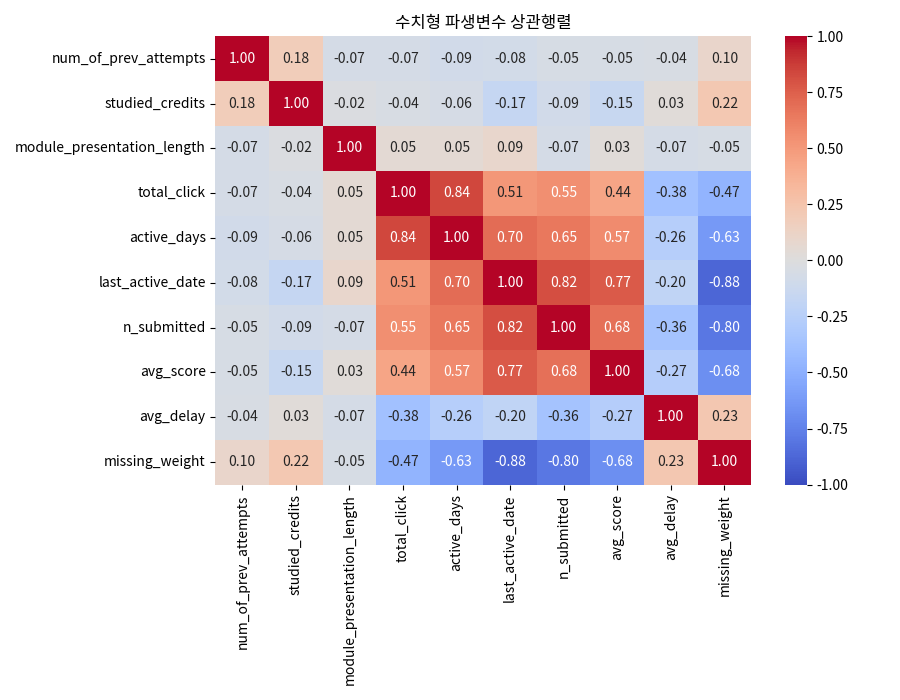

                            num_of_prev_attempts  studied_credits  module_presentation_length  total_click  active_days  last_active_date  n_submitted  \
num_of_prev_attempts                        1.00             0.18                       -0.07        -0.07        -0.09             -0.08        -0.05   
studied_credits                             0.18             1.00                       -0.02        -0.04        -0.06             -0.17        -0.09   
module_presentation_length                 -0.07            -0.02                        1.00         0.05         0.05              0.09        -0.07   
total_click                                -0.07            -0.04                        0.05         1.00         0.84              0.51         0.55   
active_days                                -0.09            -0.06                        0.05         0.84         1.00              0.70         0.65   
last_active_date                           -0.08            -0.17           

In [ ]:
# 근거 : 상관행렬
corr = X.corr().round(2)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('수치형 파생변수 상관행렬')
plt.tight_layout()
plt.show()
print(corr)

In [ ]:
# 근거 : VIF(분산팽창지수) — 10에 가까울수록 다중공선성 심각, 통상 5 이상이면 주의
Xc = X.assign(const=1.0)
vif_rows = []
for i, col in enumerate(num_cols):
    vif_rows.append((col, variance_inflation_factor(Xc.values, i)))
vif_df = pd.DataFrame(vif_rows, columns=['variable', 'VIF']).sort_values('VIF', ascending=False)
print(vif_df.round(2).to_string(index=False))

                  variable  VIF
          last_active_date 7.40
               active_days 5.11
            missing_weight 5.09
               n_submitted 4.31
               total_click 3.90
                 avg_score 2.56
                 avg_delay 1.36
module_presentation_length 1.12
           studied_credits 1.12
      num_of_prev_attempts 1.05


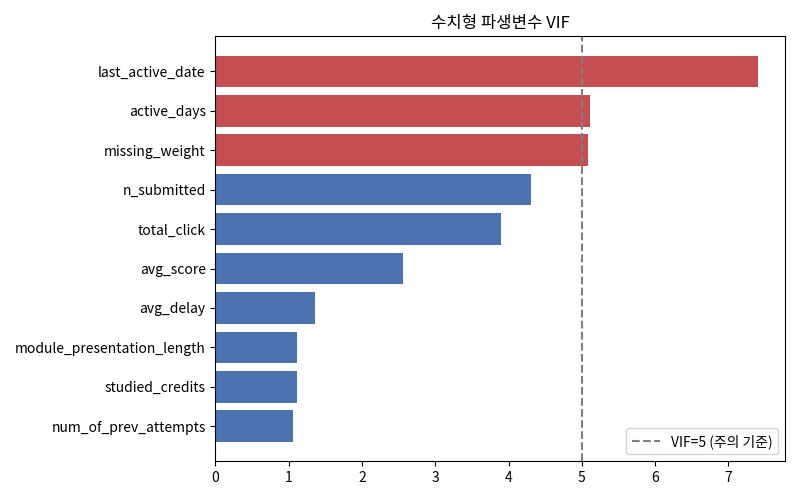

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
vif_sorted = vif_df.sort_values('VIF')
colors = ['#C44E52' if v >= 5 else '#4C72B0' for v in vif_sorted['VIF']]
ax.barh(vif_sorted['variable'], vif_sorted['VIF'], color=colors)
ax.axvline(5, color='gray', linestyle='--', label='VIF=5 (주의 기준)')
ax.set_title('수치형 파생변수 VIF')
ax.legend()
plt.tight_layout()
plt.show()

#### 설명

VIF가 5를 넘는 변수는 `last_active_date`(7.40), `active_days`(5.11), `missing_weight`(5.09) 세 개다. `n_submitted`(4.31)·`total_click`(3.90)도 낮지 않다. 상관행렬을 보면 `missing_weight`는 `last_active_date`(-0.88), `n_submitted`(-0.80), `avg_score`(-0.68), `active_days`(-0.63)와 모두 강한 음의 상관을 보이는데, 이는 결국 다섯 변수 모두 "이 학생이 얼마나 오래·활발히 참여했는가"라는 같은 축을 서로 다른 방식(클릭 수, 활동 일수, 마지막 접속일, 제출 건수, 미제출 weight)으로 측정하고 있기 때문이다.

반면 `num_of_prev_attempts`(1.05), `studied_credits`(1.12), `module_presentation_length`(1.12), `avg_delay`(1.36)는 VIF가 1대에 머물러 다른 변수와 독립적으로 움직인다 — 이 네 변수는 참여도 축과는 별개의 정보를 담고 있다고 볼 수 있다.

이후 통합·모델링 단계에서는 참여도 계열 다섯 변수(`last_active_date`, `active_days`, `missing_weight`, `n_submitted`, `total_click`)를 그대로 다 넣기보다, 대표 변수 1~2개만 선택하거나(예: `missing_weight`와 `last_active_date` 중 택1), PCA 등으로 하나의 '참여도' 축으로 합치는 방향을 검토할 필요가 있다. 다만 VIF 5~10 구간은 "심각한" 수준(통상 기준 10)까지는 아니고 "주의가 필요한" 중간 수준이므로, 트리 기반 모델(랜덤포레스트 등)처럼 다중공선성에 상대적으로 덜 민감한 모델을 쓴다면 그대로 두고 변수 중요도로 사후 판단하는 것도 가능하다.

# 4. 종합 정리

| 구분 | 핵심 결과 |
|---|---|
| Q7. 미제출-이탈 순서 | 단순 비교는 마감일 고정 때문에 착시(첫 미제출이 취소보다 나중 61.6%). 취소 이전 마감분만 보면 Withdrawn의 37.7%가 재적 중 평가를 놓쳤고, 평균 46.8일(중앙값 30일) 뒤 공식 취소 — 이 하위집단에 한해 선행 신호로 확인 |
| Q8. activity_type별 참여 | 클릭 비중은 oucontent(-4.5%p), 참여율 격차는 quiz가 최대(21.5%p, 73.6%→52.1%) — 능동적 활동에서 이탈 그룹이 더 크게 빠짐 |
| Q9. 전/후반 클릭 변화 | 이탈 그룹 79.5%가 후반부 클릭 완전히 끊김(완주 13.4%) — 지금까지 확인한 지표 중 가장 뚜렷한 이탈 신호 |
| Q10. is_banked × 재수강 | is_banked는 재수강과 정의상 종속. 재수강생 내부에서는 is_banked=1이 오히려 이탈률 낮음(27.4% vs 36.4%) — 기존 "is_banked=위험" 해석이 하위집단에서 뒤집힘 |
| 범주형 독립성 | gender-code_module(V=0.599), code_module-code_presentation(V=0.245)만 강한 연관, 나머지는 대체로 약함(V<0.14). label_churn과의 연관은 모두 약함(최대 code_module 0.177) |
| 수치형 다중공선성 | 참여도 계열 5개 변수(last_active_date·active_days·missing_weight·n_submitted·total_click) VIF 3.9~7.4로 중간 수준 다중공선성. num_of_prev_attempts·studied_credits·module_presentation_length·avg_delay는 VIF 1대로 독립적 |


이번 06번에서는 05번이 열어둔 인과 방향·시계열·해석 문제를 Q7~Q10으로 이어서 확인했고, 앞으로 모델에 넣을 변수들을 대상으로 독립성·다중공선성을 사전 점검했다. 정리하면 다음 단계로 넘어가기 전 고려할 점은 세 가지다.

1. **시계열 특징의 우선순위**: Q9에서 확인한 '전/후반 클릭 감소율'이 지금까지 파생시킨 지표 중 가장 변별력이 크다. 다음 단계에서는 이를 2~4주 단위로 더 세분화해 더 이른 시점에 탐지할 수 있는지 확인할 필요가 있다.
2. **참여도 파생변수의 정리**: Q9에서 다중공선성이 확인된 5개 참여도 변수(last_active_date·active_days·missing_weight·n_submitted·total_click)를 모두 그대로 쓸지, 대표 변수만 남길지, 혹은 하나의 지수로 합칠지 통합 단계에서 결정해야 한다.
3. **gender × code_module 해석 주의**: 두 변수의 강한 연관성(V=0.599) 때문에, 이후 모델에서 gender의 영향력으로 보이는 결과가 실제로는 과목 구성 편중에 의한 것일 수 있다는 점을 염두에 둬야 한다.

아직 전체 CSV를 하나로 합치는 통합 작업은 진행하지 않았다 — 이는 위 세 가지 판단이 끝난 뒤, 모델링을 염두에 둔 별도 단계에서 진행하는 것이 순서에 맞다.